center using training data only
        ↓
inspect numerical ranks
        ↓
apply train-only PCA truncation
        ↓
ensure kX + kY < n_train - 1
        ↓
fit ridge CCA
        ↓
evaluate the learned directions on held-out paired samples
        ↓
compare against shuffled pairs


Monte Carlo summary: first rows
--------------------------------
 p_over_n                         method  mean_regularized_objective_rho1  mean_train_abs_rho1  mean_test_abs_rho1  mean_shuffled_test_abs_rho1  mean_forced_overlap_before_pca  mean_forced_overlap_after_pca  mean_kx_after_pca  mean_ky_after_pca
      0.1 PCA + ridge CCA (lambda = 0.5)                           0.3663               0.5454              0.0142                       0.0132                             0.0                            0.0               20.0               20.0
      0.1       Ridge CCA (lambda = 0.5)                           0.3663               0.5454              0.0142                       0.0132                             0.0                            0.0               20.0               20.0
      0.1       Ridge CCA (lambda = 1.0)                           0.2767               0.5362              0.0175                       0.0109                             0.0                        

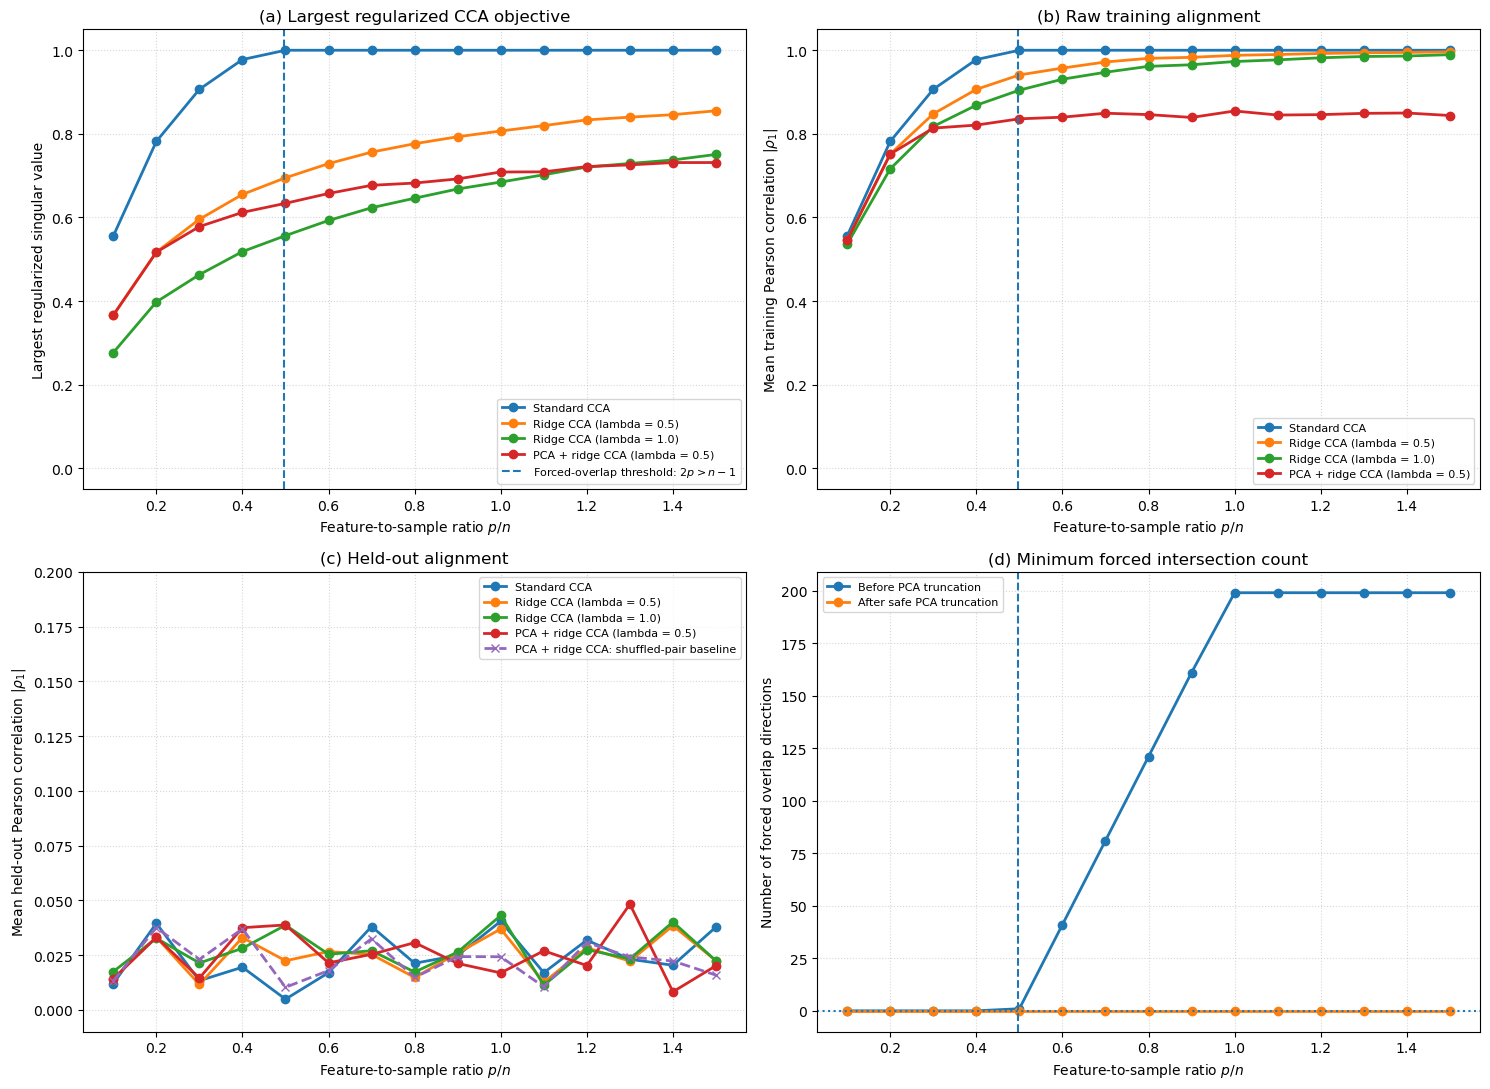

In [1]:
# ============================================================
# Rank-aware ridge CCA experiment
#
# Compares:
#   1. Standard CCA
#   2. Ridge CCA with lambda = 0.5
#   3. Ridge CCA with lambda = 1.0
#   4. PCA truncation + ridge CCA with lambda = 0.5
#
# Data:
#   X and Y are independent Gaussian noise.
#   Therefore, the population canonical correlations are all zero.
#
# Outputs:
#   - Monte Carlo summary table
#   - Rank diagnostic example
#   - Four-panel figure:
#       (a) regularized objective
#       (b) raw training correlation
#       (c) held-out correlation
#       (d) forced intersection count
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. User-adjustable simulation settings
# ============================================================

RANDOM_SEED = 123

N_TRAIN = 200
N_TEST = 1000

# Start with 5 for a reasonably quick run.
# Increase to 25 for smoother Monte Carlo curves.
N_REPLICATIONS = 5

P_RATIOS = np.arange(0.10, 1.51, 0.10)

RIDGE_LAMBDA_1 = 0.50
RIDGE_LAMBDA_2 = 1.00

# Maximum fraction of the centered sample-space dimension that
# PCA + ridge CCA may retain across both views combined.
#
# With N_TRAIN = 200:
#   ambient dimension after centering = 199
#   total retained dimensions <= floor(0.50 * 199) = 99
#
# For equally sized X and Y, this gives approximately:
#   kX = 49 and kY = 50
#
# Set this closer to 1.0 for less aggressive truncation.
SAFE_TOTAL_RANK_FRACTION = 0.50

SAVE_PLOT = True
PLOT_FILENAME = "rank_aware_ridge_cca_comparison.png"


# ============================================================
# 2. Numerical helper functions
# ============================================================

def numerical_rank_from_singular_values(singular_values, matrix_shape):
    """
    Estimate the numerical rank using a standard floating-point tolerance.
    """
    if singular_values.size == 0:
        return 0

    largest_value = singular_values[0]

    if largest_value <= 0:
        return 0

    tolerance = (
        np.finfo(float).eps
        * max(matrix_shape)
        * largest_value
    )

    return int(np.sum(singular_values > tolerance))


def componentwise_correlations(scores_x, scores_y):
    """
    Calculate Pearson correlations between corresponding score columns.

    scores_x[:, j] is compared against scores_y[:, j].

    Parameters
    ----------
    scores_x : array of shape (n_samples, n_components)
    scores_y : array of shape (n_samples, n_components)

    Returns
    -------
    correlations : array of shape (n_components,)
    """
    scores_x = np.asarray(scores_x, dtype=float)
    scores_y = np.asarray(scores_y, dtype=float)

    if scores_x.shape != scores_y.shape:
        raise ValueError(
            "scores_x and scores_y must have the same shape."
        )

    centered_x = scores_x - scores_x.mean(axis=0, keepdims=True)
    centered_y = scores_y - scores_y.mean(axis=0, keepdims=True)

    numerator = np.sum(centered_x * centered_y, axis=0)

    denominator = np.sqrt(
        np.sum(centered_x**2, axis=0)
        * np.sum(centered_y**2, axis=0)
    )

    return np.divide(
        numerator,
        denominator,
        out=np.full(scores_x.shape[1], np.nan),
        where=denominator > 0,
    )


# ============================================================
# 3. Center data and fit train-only PCA bases
# ============================================================

def prepare_training_pca(X_train, Y_train, standardize=False):
    """
    Center the training data, inspect numerical ranks, and fit PCA bases.

    Important:
    - The means are calculated using training data only.
    - Optional standard deviations are calculated using training data only.
    - PCA directions are fitted using training data only.
    - Test data are never used while fitting the model.

    Parameters
    ----------
    X_train : array of shape (n_train, p)
    Y_train : array of shape (n_train, q)
    standardize : bool
        Use False for the Gaussian simulation.
        Consider True for real datasets whose feature scales differ.

    Returns
    -------
    prepared : dict
    """
    X_train = np.asarray(X_train, dtype=float)
    Y_train = np.asarray(Y_train, dtype=float)

    if X_train.ndim != 2 or Y_train.ndim != 2:
        raise ValueError("X_train and Y_train must both be matrices.")

    if X_train.shape[0] != Y_train.shape[0]:
        raise ValueError(
            "X_train and Y_train must contain the same number "
            "of paired rows."
        )

    n_train = X_train.shape[0]

    if n_train < 3:
        raise ValueError("At least three training samples are required.")

    # --------------------------------------------------------
    # Center using training data only
    # --------------------------------------------------------
    x_mean = X_train.mean(axis=0, keepdims=True)
    y_mean = Y_train.mean(axis=0, keepdims=True)

    if standardize:
        x_scale = X_train.std(axis=0, ddof=1, keepdims=True)
        y_scale = Y_train.std(axis=0, ddof=1, keepdims=True)

        # Protect against division by zero for constant features
        x_scale = np.where(x_scale > 0, x_scale, 1.0)
        y_scale = np.where(y_scale > 0, y_scale, 1.0)
    else:
        x_scale = np.ones((1, X_train.shape[1]))
        y_scale = np.ones((1, Y_train.shape[1]))

    X_centered = (X_train - x_mean) / x_scale
    Y_centered = (Y_train - y_mean) / y_scale

    # --------------------------------------------------------
    # Thin SVD:
    #
    # X = U S V^T
    #
    # Columns of V are PCA directions in feature space.
    # --------------------------------------------------------
    _, singular_values_x, Vt_x = np.linalg.svd(
        X_centered,
        full_matrices=False,
    )

    _, singular_values_y, Vt_y = np.linalg.svd(
        Y_centered,
        full_matrices=False,
    )

    rank_x = numerical_rank_from_singular_values(
        singular_values_x,
        X_centered.shape,
    )

    rank_y = numerical_rank_from_singular_values(
        singular_values_y,
        Y_centered.shape,
    )

    if rank_x == 0 or rank_y == 0:
        raise ValueError(
            "At least one centered matrix has numerical rank zero."
        )

    ambient_dimension = n_train - 1

    forced_overlap_before_pca = max(
        0,
        rank_x + rank_y - ambient_dimension,
    )

    return {
        "X_centered": X_centered,
        "Y_centered": Y_centered,
        "x_mean": x_mean,
        "y_mean": y_mean,
        "x_scale": x_scale,
        "y_scale": y_scale,
        "x_full_pca_basis": Vt_x[:rank_x].T,
        "y_full_pca_basis": Vt_y[:rank_y].T,
        "rank_x": rank_x,
        "rank_y": rank_y,
        "n_train": n_train,
        "ambient_dimension": ambient_dimension,
        "forced_overlap_before_pca": forced_overlap_before_pca,
    }


# ============================================================
# 4. Select safe retained PCA ranks
# ============================================================

def choose_safe_pca_ranks(
    rank_x,
    rank_y,
    n_train,
    max_total_fraction=0.50,
):
    """
    Choose PCA ranks kX and kY such that:

        kX + kY < n_train - 1

    This explicitly removes forced intersection directions.

    The max_total_fraction parameter controls how conservative
    the PCA truncation is.

    Parameters
    ----------
    rank_x : int
        Numerical rank of centered X.
    rank_y : int
        Numerical rank of centered Y.
    n_train : int
        Number of paired training rows.
    max_total_fraction : float in (0, 1]
        Maximum fraction of the centered ambient dimension to retain
        across both views combined.

    Returns
    -------
    kx : int
    ky : int
    """
    if not (0 < max_total_fraction <= 1):
        raise ValueError(
            "max_total_fraction must lie inside the interval (0, 1]."
        )

    if rank_x < 1 or rank_y < 1:
        raise ValueError("Both matrices must have positive rank.")

    # Since we require:
    #     kX + kY < n_train - 1
    # the largest allowed integer total is:
    #     n_train - 2
    strict_budget = n_train - 2

    preferred_budget = max(
        2,
        int(np.floor(max_total_fraction * (n_train - 1))),
    )

    total_budget = min(
        strict_budget,
        preferred_budget,
        rank_x + rank_y,
    )

    if total_budget < 2:
        raise ValueError(
            "The rank budget is too small to retain at least one "
            "component from each view."
        )

    # Allocate retained dimensions approximately in proportion
    # to the original numerical ranks.
    kx = min(
        rank_x,
        max(
            1,
            int(
                np.floor(
                    total_budget
                    * rank_x
                    / (rank_x + rank_y)
                )
            ),
        ),
    )

    ky = min(
        rank_y,
        max(1, total_budget - kx),
    )

    # Use any remaining budget if one side reached its cap early
    while kx + ky < total_budget:
        if kx < rank_x:
            kx += 1
        elif ky < rank_y:
            ky += 1
        else:
            break

    # Defensive check for the strict inequality
    while kx + ky >= n_train - 1:
        if kx >= ky and kx > 1:
            kx -= 1
        elif ky > 1:
            ky -= 1
        else:
            raise ValueError(
                "Unable to construct positive safe PCA ranks."
            )

    return int(kx), int(ky)


# ============================================================
# 5. Fit ridge CCA after an optional PCA truncation
# ============================================================

def fit_pca_rcca(
    prepared,
    lam,
    kx=None,
    ky=None,
    enforce_no_forced_overlap=False,
):
    """
    Fit ridge CCA after selecting PCA components.

    This function supports all three cases:

    1. Ordinary CCA:
       lam = 0
       kx = rank(X)
       ky = rank(Y)

    2. Ridge-only CCA:
       lam > 0
       kx = rank(X)
       ky = rank(Y)

    3. PCA + ridge CCA:
       lam > 0
       kx and ky are reduced
       enforce_no_forced_overlap = True

    The covariance denominator is n rather than n - 1 to match
    the original ridge-CCA code.

    Parameters
    ----------
    prepared : dict
        Output from prepare_training_pca().
    lam : float
        Ridge penalty.
    kx : int or None
        Number of PCA components retained from X.
    ky : int or None
        Number of PCA components retained from Y.
    enforce_no_forced_overlap : bool
        Raise an error unless kX + kY < n_train - 1.

    Returns
    -------
    model : dict
    """
    if lam < 0:
        raise ValueError("The ridge penalty must be non-negative.")

    rank_x = prepared["rank_x"]
    rank_y = prepared["rank_y"]

    ambient_dimension = prepared["ambient_dimension"]

    if kx is None:
        kx = rank_x

    if ky is None:
        ky = rank_y

    kx = int(kx)
    ky = int(ky)

    if not (1 <= kx <= rank_x):
        raise ValueError(
            f"kx must satisfy 1 <= kx <= {rank_x}."
        )

    if not (1 <= ky <= rank_y):
        raise ValueError(
            f"ky must satisfy 1 <= ky <= {rank_y}."
        )

    if (
        enforce_no_forced_overlap
        and kx + ky >= ambient_dimension
    ):
        raise ValueError(
            "Unsafe PCA truncation: need "
            "kX + kY < n_train - 1, but got "
            f"{kx} + {ky} >= {ambient_dimension}."
        )

    # --------------------------------------------------------
    # Retain selected PCA feature-space directions
    # --------------------------------------------------------
    P_x = prepared["x_full_pca_basis"][:, :kx]
    P_y = prepared["y_full_pca_basis"][:, :ky]

    X_reduced = prepared["X_centered"] @ P_x
    Y_reduced = prepared["Y_centered"] @ P_y

    n_train = prepared["n_train"]

    # --------------------------------------------------------
    # Covariance matrices in PCA coordinates
    #
    # Since PCA coordinates are orthogonal, S_xx and S_yy are
    # diagonal up to floating-point error.
    #
    # Exploiting this structure avoids unnecessary expensive
    # matrix eigendecompositions.
    # --------------------------------------------------------
    variance_x = np.sum(X_reduced**2, axis=0) / n_train
    variance_y = np.sum(Y_reduced**2, axis=0) / n_train

    S_xy = (X_reduced.T @ Y_reduced) / n_train

    inverse_sqrt_x = 1.0 / np.sqrt(variance_x + lam)
    inverse_sqrt_y = 1.0 / np.sqrt(variance_y + lam)

    # --------------------------------------------------------
    # Regularized whitened cross-covariance:
    #
    # T = (S_xx + lambda I)^(-1/2)
    #     S_xy
    #     (S_yy + lambda I)^(-1/2)
    # --------------------------------------------------------
    T_matrix = (
        inverse_sqrt_x[:, None]
        * S_xy
        * inverse_sqrt_y[None, :]
    )

    U, regularized_singular_values, Vt = np.linalg.svd(
        T_matrix,
        full_matrices=False,
    )

    # Directions inside the PCA-reduced feature spaces
    A_reduced = inverse_sqrt_x[:, None] * U
    B_reduced = inverse_sqrt_y[:, None] * Vt.T

    # --------------------------------------------------------
    # Raw Pearson correlations of fitted training projections
    #
    # These differ from regularized_singular_values whenever
    # lambda > 0.
    # --------------------------------------------------------
    train_scores_x = X_reduced @ A_reduced
    train_scores_y = Y_reduced @ B_reduced

    train_correlations = componentwise_correlations(
        train_scores_x,
        train_scores_y,
    )

    diagnostics = {
        "n_train": n_train,
        "ambient_dimension_after_centering": ambient_dimension,
        "rank_x_before_pca": rank_x,
        "rank_y_before_pca": rank_y,
        "forced_overlap_before_pca": max(
            0,
            rank_x + rank_y - ambient_dimension,
        ),
        "kx_after_pca": kx,
        "ky_after_pca": ky,
        "forced_overlap_after_pca": max(
            0,
            kx + ky - ambient_dimension,
        ),
        "lambda": lam,
    }

    return {
        "x_mean": prepared["x_mean"],
        "y_mean": prepared["y_mean"],
        "x_scale": prepared["x_scale"],
        "y_scale": prepared["y_scale"],
        "P_x": P_x,
        "P_y": P_y,
        "A_reduced": A_reduced,
        "B_reduced": B_reduced,
        "regularized_singular_values": regularized_singular_values,
        "train_correlations": train_correlations,
        "diagnostics": diagnostics,
    }


# ============================================================
# 6. Evaluate learned directions without refitting
# ============================================================

def evaluate_pca_rcca(model, X, Y):
    """
    Evaluate already-fitted CCA directions on paired rows.

    This function does not refit:
    - the centering constants
    - the scales
    - PCA
    - CCA directions

    Parameters
    ----------
    model : dict
        Output from fit_pca_rcca().
    X : array of shape (n_samples, p)
    Y : array of shape (n_samples, q)

    Returns
    -------
    correlations : array
        Pearson correlations between corresponding projected components.
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must both be matrices.")

    if X.shape[0] != Y.shape[0]:
        raise ValueError(
            "X and Y must contain the same number of paired rows."
        )

    X_reduced = (
        (X - model["x_mean"])
        / model["x_scale"]
    ) @ model["P_x"]

    Y_reduced = (
        (Y - model["y_mean"])
        / model["y_scale"]
    ) @ model["P_y"]

    scores_x = X_reduced @ model["A_reduced"]
    scores_y = Y_reduced @ model["B_reduced"]

    return componentwise_correlations(
        scores_x,
        scores_y,
    )


# ============================================================
# 7. Run the Monte Carlo experiment
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

rows = []

for ratio in P_RATIOS:
    p = int(np.floor(N_TRAIN * ratio))

    for replication in range(N_REPLICATIONS):

        # ----------------------------------------------------
        # Independent Gaussian views:
        #
        # There is no shared population signal.
        # Every genuine population canonical correlation is zero.
        # ----------------------------------------------------
        X_train = rng.standard_normal((N_TRAIN, p))
        Y_train = rng.standard_normal((N_TRAIN, p))

        X_test = rng.standard_normal((N_TEST, p))
        Y_test = rng.standard_normal((N_TEST, p))

        # ----------------------------------------------------
        # Center, inspect ranks, and prepare PCA bases
        # ----------------------------------------------------
        prepared = prepare_training_pca(
            X_train,
            Y_train,
            standardize=False,
        )

        # ----------------------------------------------------
        # Select safe retained ranks:
        #
        # kX + kY < N_TRAIN - 1
        # ----------------------------------------------------
        safe_kx, safe_ky = choose_safe_pca_ranks(
            rank_x=prepared["rank_x"],
            rank_y=prepared["rank_y"],
            n_train=N_TRAIN,
            max_total_fraction=SAFE_TOTAL_RANK_FRACTION,
        )

        # ----------------------------------------------------
        # Fit four models
        # ----------------------------------------------------
        models = {
            "Standard CCA": fit_pca_rcca(
                prepared=prepared,
                lam=0.0,
                kx=prepared["rank_x"],
                ky=prepared["rank_y"],
                enforce_no_forced_overlap=False,
            ),

            f"Ridge CCA (lambda = {RIDGE_LAMBDA_1})": fit_pca_rcca(
                prepared=prepared,
                lam=RIDGE_LAMBDA_1,
                kx=prepared["rank_x"],
                ky=prepared["rank_y"],
                enforce_no_forced_overlap=False,
            ),

            f"Ridge CCA (lambda = {RIDGE_LAMBDA_2})": fit_pca_rcca(
                prepared=prepared,
                lam=RIDGE_LAMBDA_2,
                kx=prepared["rank_x"],
                ky=prepared["rank_y"],
                enforce_no_forced_overlap=False,
            ),

            f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA_1})": fit_pca_rcca(
                prepared=prepared,
                lam=RIDGE_LAMBDA_1,
                kx=safe_kx,
                ky=safe_ky,
                enforce_no_forced_overlap=True,
            ),
        }

        # ----------------------------------------------------
        # Null baseline:
        #
        # Shuffle Y rows to destroy the pairing.
        # ----------------------------------------------------
        shuffled_indices = rng.permutation(N_TEST)

        for method_name, model in models.items():

            test_correlations = evaluate_pca_rcca(
                model,
                X_test,
                Y_test,
            )

            shuffled_test_correlations = evaluate_pca_rcca(
                model,
                X_test,
                Y_test[shuffled_indices],
            )

            diagnostics = model["diagnostics"]

            rows.append(
                {
                    "p_over_n": ratio,
                    "p": p,
                    "replication": replication,
                    "method": method_name,

                    # This matches the type of value plotted in
                    # the original ridge-CCA graph.
                    "regularized_objective_rho1": (
                        model["regularized_singular_values"][0]
                    ),

                    # Raw Pearson correlation between the fitted
                    # training score vectors.
                    "train_abs_rho1": abs(
                        model["train_correlations"][0]
                    ),

                    # Pearson correlation after directions are
                    # frozen and evaluated on unseen paired rows.
                    "test_abs_rho1": abs(
                        test_correlations[0]
                    ),

                    # Held-out null baseline after breaking pairs.
                    "shuffled_test_abs_rho1": abs(
                        shuffled_test_correlations[0]
                    ),

                    "rank_x_before_pca": (
                        diagnostics["rank_x_before_pca"]
                    ),

                    "rank_y_before_pca": (
                        diagnostics["rank_y_before_pca"]
                    ),

                    "forced_overlap_before_pca": (
                        diagnostics["forced_overlap_before_pca"]
                    ),

                    "kx_after_pca": (
                        diagnostics["kx_after_pca"]
                    ),

                    "ky_after_pca": (
                        diagnostics["ky_after_pca"]
                    ),

                    "forced_overlap_after_pca": (
                        diagnostics["forced_overlap_after_pca"]
                    ),
                }
            )


results = pd.DataFrame(rows)


# ============================================================
# 8. Summarize Monte Carlo averages
# ============================================================

summary = (
    results
    .groupby(
        ["p_over_n", "method"],
        as_index=False,
    )
    .agg(
        mean_regularized_objective_rho1=(
            "regularized_objective_rho1",
            "mean",
        ),

        mean_train_abs_rho1=(
            "train_abs_rho1",
            "mean",
        ),

        mean_test_abs_rho1=(
            "test_abs_rho1",
            "mean",
        ),

        mean_shuffled_test_abs_rho1=(
            "shuffled_test_abs_rho1",
            "mean",
        ),

        mean_forced_overlap_before_pca=(
            "forced_overlap_before_pca",
            "mean",
        ),

        mean_forced_overlap_after_pca=(
            "forced_overlap_after_pca",
            "mean",
        ),

        mean_kx_after_pca=(
            "kx_after_pca",
            "mean",
        ),

        mean_ky_after_pca=(
            "ky_after_pca",
            "mean",
        ),
    )
)


# ============================================================
# 9. Print a compact summary and one rank-diagnostic example
# ============================================================

print()
print("Monte Carlo summary: first rows")
print("--------------------------------")
print(summary.head(12).round(4).to_string(index=False))

diagnostic_method = (
    f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA_1})"
)

diagnostic_ratio = 1.20

diagnostic_rows = results[
    (results["method"] == diagnostic_method)
    & np.isclose(results["p_over_n"], diagnostic_ratio)
]

if not diagnostic_rows.empty:
    diagnostic_example = diagnostic_rows.iloc[0]

    print()
    print(f"Rank diagnostic example at p/n = {diagnostic_ratio:.2f}")
    print("------------------------------------------------")

    print(
        "rank(X) before PCA:",
        int(diagnostic_example["rank_x_before_pca"]),
    )

    print(
        "rank(Y) before PCA:",
        int(diagnostic_example["rank_y_before_pca"]),
    )

    print(
        "ambient sample-space dimension after centering:",
        N_TRAIN - 1,
    )

    print(
        "minimum forced overlap before PCA:",
        int(diagnostic_example["forced_overlap_before_pca"]),
    )

    print(
        "retained kX after PCA:",
        int(diagnostic_example["kx_after_pca"]),
    )

    print(
        "retained kY after PCA:",
        int(diagnostic_example["ky_after_pca"]),
    )

    print(
        "minimum forced overlap after PCA:",
        int(diagnostic_example["forced_overlap_after_pca"]),
    )


# ============================================================
# 10. Create the four-panel comparison figure
# ============================================================

method_order = [
    "Standard CCA",
    f"Ridge CCA (lambda = {RIDGE_LAMBDA_1})",
    f"Ridge CCA (lambda = {RIDGE_LAMBDA_2})",
    f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA_1})",
]

# Since p = q in this experiment, exact forced overlap begins
# approximately when:
#
#     2p > n_train - 1
#
# or:
#
#     p / n_train > (n_train - 1) / (2 n_train)
#
forced_overlap_threshold = (
    (N_TRAIN - 1)
    / (2 * N_TRAIN)
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11),
)


# ------------------------------------------------------------
# Plot (a): regularized objective
#
# This is the apples-to-apples counterpart of the original
# ridge-CCA figure.
# ------------------------------------------------------------
ax = axes[0, 0]

for method in method_order:
    subset = summary[
        summary["method"] == method
    ]

    ax.plot(
        subset["p_over_n"],
        subset["mean_regularized_objective_rho1"],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.axvline(
    forced_overlap_threshold,
    linestyle="--",
    linewidth=1.5,
    label=r"Forced-overlap threshold: $2p > n - 1$",
)

ax.set_title(
    "(a) Largest regularized CCA objective"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Largest regularized singular value"
)

ax.set_ylim(-0.05, 1.05)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (b): raw Pearson training correlation
#
# Ridge may shrink the objective while raw training correlation
# remains high.
# ------------------------------------------------------------
ax = axes[0, 1]

for method in method_order:
    subset = summary[
        summary["method"] == method
    ]

    ax.plot(
        subset["p_over_n"],
        subset["mean_train_abs_rho1"],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.axvline(
    forced_overlap_threshold,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    "(b) Raw training alignment"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean training Pearson correlation $|\rho_1|$"
)

ax.set_ylim(-0.05, 1.05)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (c): held-out Pearson correlation
#
# Because X and Y are independent noise, a valid method should
# produce held-out correlation close to zero.
# ------------------------------------------------------------
ax = axes[1, 0]

for method in method_order:
    subset = summary[
        summary["method"] == method
    ]

    ax.plot(
        subset["p_over_n"],
        subset["mean_test_abs_rho1"],
        marker="o",
        linewidth=2,
        label=method,
    )

pca_ridge_subset = summary[
    summary["method"] == diagnostic_method
]

ax.plot(
    pca_ridge_subset["p_over_n"],
    pca_ridge_subset["mean_shuffled_test_abs_rho1"],
    marker="x",
    linestyle="--",
    linewidth=2,
    label="PCA + ridge CCA: shuffled-pair baseline",
)

ax.set_title(
    "(c) Held-out alignment"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean held-out Pearson correlation $|\rho_1|$"
)

ax.set_ylim(-0.01, 0.20)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (d): forced intersections before and after PCA
#
# Ridge alone cannot explicitly remove these directions.
# PCA truncation can.
# ------------------------------------------------------------
ax = axes[1, 1]

standard_subset = summary[
    summary["method"] == "Standard CCA"
]

pca_ridge_subset = summary[
    summary["method"] == diagnostic_method
]

ax.plot(
    standard_subset["p_over_n"],
    standard_subset["mean_forced_overlap_before_pca"],
    marker="o",
    linewidth=2,
    label="Before PCA truncation",
)

ax.plot(
    pca_ridge_subset["p_over_n"],
    pca_ridge_subset["mean_forced_overlap_after_pca"],
    marker="o",
    linewidth=2,
    label="After safe PCA truncation",
)

ax.axvline(
    forced_overlap_threshold,
    linestyle="--",
    linewidth=1.5,
)

ax.axhline(
    0,
    linestyle=":",
    linewidth=1.5,
)

ax.set_title(
    "(d) Minimum forced intersection count"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    "Number of forced overlap directions"
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


plt.tight_layout()

if SAVE_PLOT:
    plt.savefig(
        PLOT_FILENAME,
        dpi=200,
        bbox_inches="tight",
    )

plt.show()


Summary preview
---------------
         scenario  p_over_n                         method  mean_regularized_objective_rho1  mean_train_abs_rho1  mean_held_out_abs_rho1  mean_shuffled_held_out_abs_rho1  mean_forced_overlap_before_pca  mean_forced_overlap_after_pca
Independent noise       0.1 PCA + ridge CCA (lambda = 0.5)                           0.3646               0.5528                  0.0242                           0.0331                             0.0                            0.0
Independent noise       0.1       Ridge CCA (lambda = 0.5)                           0.3646               0.5528                  0.0242                           0.0331                             0.0                            0.0
Independent noise       0.1                   Standard CCA                           0.5687               0.5687                  0.0154                           0.0267                             0.0                            0.0
Independent noise       0.2 PCA + r

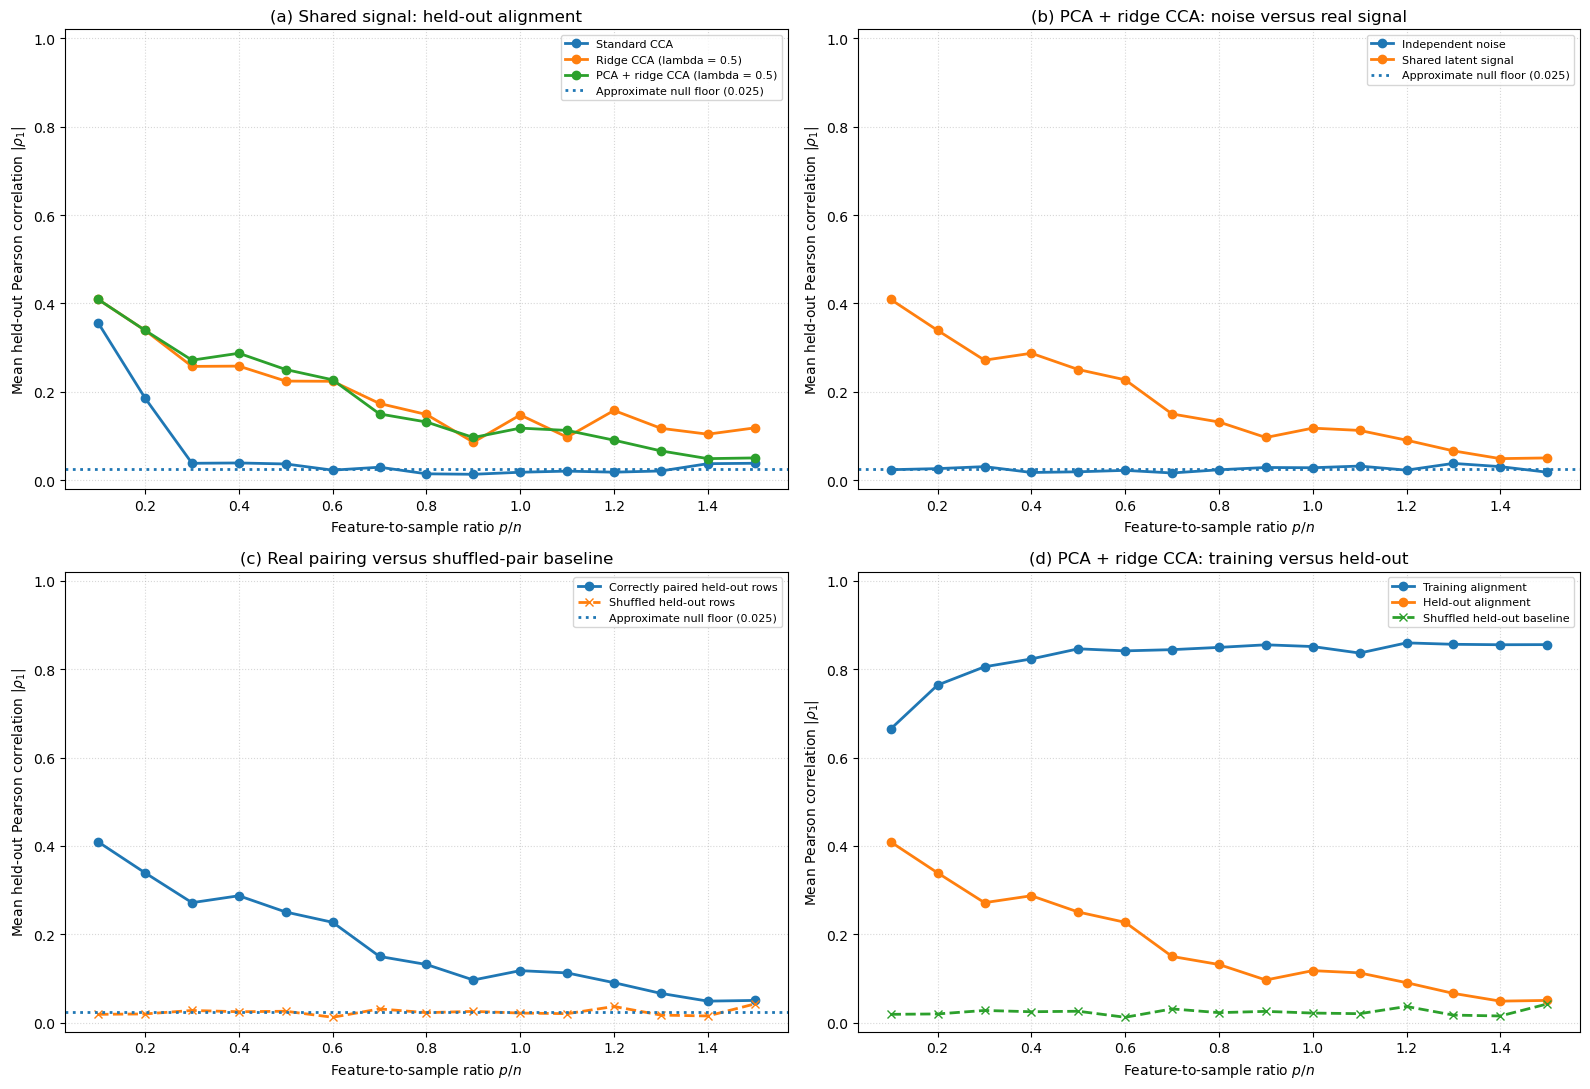

In [2]:
# ============================================================
# Controlled shared-signal experiment for rank-aware CCA
#
# Compares:
#   1. Standard CCA
#   2. Ridge CCA
#   3. PCA truncation + ridge CCA
#
# Runs two scenarios:
#   A. independent noise
#   B. genuine shared latent signal
#
# Key diagnostic:
#   Fit directions on training rows only.
#   Freeze those directions.
#   Evaluate correlation on unseen paired test rows.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. User-adjustable settings
# ============================================================

RANDOM_SEED = 123

N_TRAIN = 200
N_TEST = 1000

# Increase to 20 or 30 for smoother curves.
N_REPLICATIONS = 5

P_RATIOS = np.arange(0.10, 1.51, 0.10)

RIDGE_LAMBDA = 0.50

# Maximum total retained PCA rank across X and Y:
#
#     kX + kY <= floor(
#         SAFE_TOTAL_RANK_FRACTION * (N_TRAIN - 1)
#     )
#
SAFE_TOTAL_RANK_FRACTION = 0.50

# Shared latent model settings
LATENT_DIMENSION = 3

# Increase this for easier signal recovery.
SIGNAL_STRENGTH = 1.00

# Increase this to make recovery harder.
NOISE_STD = 1.00

SAVE_PLOT = True

PLOT_FILENAME = "controlled_shared_signal_cca.png"


# ============================================================
# 2. Basic helper functions
# ============================================================

def numerical_rank_from_singular_values(
    singular_values,
    matrix_shape,
):
    """
    Estimate numerical matrix rank using a standard
    floating-point tolerance.
    """
    if singular_values.size == 0:
        return 0

    largest_value = singular_values[0]

    if largest_value <= 0:
        return 0

    tolerance = (
        np.finfo(float).eps
        * max(matrix_shape)
        * largest_value
    )

    return int(
        np.sum(singular_values > tolerance)
    )


def componentwise_correlations(
    scores_x,
    scores_y,
):
    """
    Pearson correlations between corresponding columns.

    scores_x[:, j] is compared against scores_y[:, j].
    """
    scores_x = np.asarray(
        scores_x,
        dtype=float,
    )

    scores_y = np.asarray(
        scores_y,
        dtype=float,
    )

    if scores_x.shape != scores_y.shape:
        raise ValueError(
            "scores_x and scores_y must have the same shape."
        )

    centered_x = (
        scores_x
        - scores_x.mean(
            axis=0,
            keepdims=True,
        )
    )

    centered_y = (
        scores_y
        - scores_y.mean(
            axis=0,
            keepdims=True,
        )
    )

    numerator = np.sum(
        centered_x * centered_y,
        axis=0,
    )

    denominator = np.sqrt(
        np.sum(
            centered_x**2,
            axis=0,
        )
        * np.sum(
            centered_y**2,
            axis=0,
        )
    )

    return np.divide(
        numerator,
        denominator,
        out=np.full(
            scores_x.shape[1],
            np.nan,
        ),
        where=denominator > 0,
    )


# ============================================================
# 3. Generate data
# ============================================================

def orthonormal_loading_matrix(
    rng,
    n_features,
    latent_dimension,
):
    """
    Create feature-space loading directions with orthonormal
    columns.

    This controls signal strength across different values of p.
    Without normalization, increasing p could accidentally increase
    the total signal magnitude.
    """
    if latent_dimension > n_features:
        raise ValueError(
            "latent_dimension cannot exceed n_features."
        )

    random_matrix = rng.standard_normal(
        (
            n_features,
            latent_dimension,
        )
    )

    Q, _ = np.linalg.qr(
        random_matrix,
    )

    return Q[:, :latent_dimension]


def generate_paired_data(
    rng,
    n_samples,
    loading_x,
    loading_y,
    signal_strength,
    noise_std,
):
    """
    Generate paired observations:

        X = signal_strength * Z @ loading_x.T + noise_x
        Y = signal_strength * Z @ loading_y.T + noise_y

    X and Y share the same latent rows Z.
    """
    latent_dimension = loading_x.shape[1]

    if loading_y.shape[1] != latent_dimension:
        raise ValueError(
            "loading_x and loading_y must use the same "
            "latent dimension."
        )

    Z = rng.standard_normal(
        (
            n_samples,
            latent_dimension,
        )
    )

    noise_x = noise_std * rng.standard_normal(
        (
            n_samples,
            loading_x.shape[0],
        )
    )

    noise_y = noise_std * rng.standard_normal(
        (
            n_samples,
            loading_y.shape[0],
        )
    )

    X = (
        signal_strength
        * Z
        @ loading_x.T
        + noise_x
    )

    Y = (
        signal_strength
        * Z
        @ loading_y.T
        + noise_y
    )

    return X, Y, Z


# ============================================================
# 4. Prepare training PCA and inspect ranks
# ============================================================

def prepare_training_pca(
    X_train,
    Y_train,
    standardize=False,
):
    """
    Center using training rows only, inspect numerical ranks,
    and calculate train-only PCA bases.
    """
    X_train = np.asarray(
        X_train,
        dtype=float,
    )

    Y_train = np.asarray(
        Y_train,
        dtype=float,
    )

    if X_train.ndim != 2 or Y_train.ndim != 2:
        raise ValueError(
            "X_train and Y_train must both be matrices."
        )

    if X_train.shape[0] != Y_train.shape[0]:
        raise ValueError(
            "X_train and Y_train must have the same number "
            "of paired rows."
        )

    n_train = X_train.shape[0]

    x_mean = X_train.mean(
        axis=0,
        keepdims=True,
    )

    y_mean = Y_train.mean(
        axis=0,
        keepdims=True,
    )

    if standardize:
        x_scale = X_train.std(
            axis=0,
            ddof=1,
            keepdims=True,
        )

        y_scale = Y_train.std(
            axis=0,
            ddof=1,
            keepdims=True,
        )

        x_scale = np.where(
            x_scale > 0,
            x_scale,
            1.0,
        )

        y_scale = np.where(
            y_scale > 0,
            y_scale,
            1.0,
        )

    else:
        x_scale = np.ones(
            (
                1,
                X_train.shape[1],
            )
        )

        y_scale = np.ones(
            (
                1,
                Y_train.shape[1],
            )
        )

    X_centered = (
        X_train - x_mean
    ) / x_scale

    Y_centered = (
        Y_train - y_mean
    ) / y_scale

    _, singular_values_x, Vt_x = np.linalg.svd(
        X_centered,
        full_matrices=False,
    )

    _, singular_values_y, Vt_y = np.linalg.svd(
        Y_centered,
        full_matrices=False,
    )

    rank_x = numerical_rank_from_singular_values(
        singular_values_x,
        X_centered.shape,
    )

    rank_y = numerical_rank_from_singular_values(
        singular_values_y,
        Y_centered.shape,
    )

    ambient_dimension = n_train - 1

    return {
        "X_centered": X_centered,
        "Y_centered": Y_centered,
        "x_mean": x_mean,
        "y_mean": y_mean,
        "x_scale": x_scale,
        "y_scale": y_scale,
        "x_full_pca_basis": Vt_x[:rank_x].T,
        "y_full_pca_basis": Vt_y[:rank_y].T,
        "rank_x": rank_x,
        "rank_y": rank_y,
        "n_train": n_train,
        "ambient_dimension": ambient_dimension,
        "forced_overlap_before_pca": max(
            0,
            rank_x
            + rank_y
            - ambient_dimension,
        ),
    }


# ============================================================
# 5. Choose safe PCA dimensions
# ============================================================

def choose_safe_pca_ranks(
    rank_x,
    rank_y,
    n_train,
    max_total_fraction=0.50,
):
    """
    Select retained PCA ranks satisfying:

        kX + kY < n_train - 1
    """
    if not (
        0
        < max_total_fraction
        <= 1
    ):
        raise ValueError(
            "max_total_fraction must be inside (0, 1]."
        )

    strict_budget = n_train - 2

    preferred_budget = max(
        2,
        int(
            np.floor(
                max_total_fraction
                * (n_train - 1)
            )
        ),
    )

    total_budget = min(
        strict_budget,
        preferred_budget,
        rank_x + rank_y,
    )

    kx = min(
        rank_x,
        max(
            1,
            int(
                np.floor(
                    total_budget
                    * rank_x
                    / (rank_x + rank_y)
                )
            ),
        ),
    )

    ky = min(
        rank_y,
        max(
            1,
            total_budget - kx,
        ),
    )

    while kx + ky < total_budget:
        if kx < rank_x:
            kx += 1

        elif ky < rank_y:
            ky += 1

        else:
            break

    while kx + ky >= n_train - 1:
        if kx >= ky and kx > 1:
            kx -= 1

        elif ky > 1:
            ky -= 1

        else:
            raise ValueError(
                "Unable to construct safe PCA ranks."
            )

    return int(kx), int(ky)


# ============================================================
# 6. Fit PCA-truncated ridge CCA
# ============================================================

def fit_pca_rcca(
    prepared,
    lam,
    kx=None,
    ky=None,
    enforce_no_forced_overlap=False,
):
    """
    Fit ordinary CCA, ridge CCA, or PCA + ridge CCA.

    Cases:
    - ordinary CCA:
        lam = 0 and full retained ranks

    - ridge-only CCA:
        lam > 0 and full retained ranks

    - PCA + ridge CCA:
        lam > 0 and reduced safe ranks
    """
    if lam < 0:
        raise ValueError(
            "lam must be non-negative."
        )

    rank_x = prepared["rank_x"]
    rank_y = prepared["rank_y"]

    ambient_dimension = (
        prepared["ambient_dimension"]
    )

    if kx is None:
        kx = rank_x

    if ky is None:
        ky = rank_y

    kx = int(kx)
    ky = int(ky)

    if enforce_no_forced_overlap:
        if kx + ky >= ambient_dimension:
            raise ValueError(
                "Unsafe retained ranks. Need "
                "kX + kY < n_train - 1."
            )

    P_x = (
        prepared["x_full_pca_basis"]
        [:, :kx]
    )

    P_y = (
        prepared["y_full_pca_basis"]
        [:, :ky]
    )

    X_reduced = (
        prepared["X_centered"]
        @ P_x
    )

    Y_reduced = (
        prepared["Y_centered"]
        @ P_y
    )

    n_train = prepared["n_train"]

    variance_x = (
        np.sum(
            X_reduced**2,
            axis=0,
        )
        / n_train
    )

    variance_y = (
        np.sum(
            Y_reduced**2,
            axis=0,
        )
        / n_train
    )

    S_xy = (
        X_reduced.T
        @ Y_reduced
    ) / n_train

    inverse_sqrt_x = (
        1.0
        / np.sqrt(
            variance_x + lam
        )
    )

    inverse_sqrt_y = (
        1.0
        / np.sqrt(
            variance_y + lam
        )
    )

    T_matrix = (
        inverse_sqrt_x[:, None]
        * S_xy
        * inverse_sqrt_y[None, :]
    )

    U, singular_values, Vt = np.linalg.svd(
        T_matrix,
        full_matrices=False,
    )

    A_reduced = (
        inverse_sqrt_x[:, None]
        * U
    )

    B_reduced = (
        inverse_sqrt_y[:, None]
        * Vt.T
    )

    train_scores_x = (
        X_reduced
        @ A_reduced
    )

    train_scores_y = (
        Y_reduced
        @ B_reduced
    )

    train_correlations = (
        componentwise_correlations(
            train_scores_x,
            train_scores_y,
        )
    )

    return {
        "x_mean": prepared["x_mean"],
        "y_mean": prepared["y_mean"],
        "x_scale": prepared["x_scale"],
        "y_scale": prepared["y_scale"],
        "P_x": P_x,
        "P_y": P_y,
        "A_reduced": A_reduced,
        "B_reduced": B_reduced,
        "regularized_singular_values": singular_values,
        "train_correlations": train_correlations,
        "rank_x_before_pca": rank_x,
        "rank_y_before_pca": rank_y,
        "kx_after_pca": kx,
        "ky_after_pca": ky,
        "forced_overlap_before_pca": max(
            0,
            rank_x
            + rank_y
            - ambient_dimension,
        ),
        "forced_overlap_after_pca": max(
            0,
            kx
            + ky
            - ambient_dimension,
        ),
    }


# ============================================================
# 7. Evaluate fixed learned directions on new samples
# ============================================================

def evaluate_pca_rcca(
    model,
    X,
    Y,
):
    """
    Calculate held-out correlations.

    Crucially:
    - do not calculate a new PCA basis;
    - do not refit CCA;
    - do not select new directions.

    Apply the frozen training directions to unseen samples.
    """
    X = np.asarray(
        X,
        dtype=float,
    )

    Y = np.asarray(
        Y,
        dtype=float,
    )

    X_reduced = (
        (
            X
            - model["x_mean"]
        )
        / model["x_scale"]
    ) @ model["P_x"]

    Y_reduced = (
        (
            Y
            - model["y_mean"]
        )
        / model["y_scale"]
    ) @ model["P_y"]

    scores_x = (
        X_reduced
        @ model["A_reduced"]
    )

    scores_y = (
        Y_reduced
        @ model["B_reduced"]
    )

    return componentwise_correlations(
        scores_x,
        scores_y,
    )


# ============================================================
# 8. Run both scenarios
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

rows = []

scenarios = {
    "Independent noise": 0.0,
    "Shared latent signal": SIGNAL_STRENGTH,
}

for scenario_name, scenario_signal_strength in scenarios.items():

    for ratio in P_RATIOS:

        p = int(
            np.floor(
                N_TRAIN * ratio
            )
        )

        if p < LATENT_DIMENSION:
            continue

        for replication in range(
            N_REPLICATIONS
        ):

            # ------------------------------------------------
            # Fixed feature-space latent directions
            #
            # The same loading matrices are used for train and
            # test data. Only the observations themselves change.
            # ------------------------------------------------
            loading_x = orthonormal_loading_matrix(
                rng=rng,
                n_features=p,
                latent_dimension=LATENT_DIMENSION,
            )

            loading_y = orthonormal_loading_matrix(
                rng=rng,
                n_features=p,
                latent_dimension=LATENT_DIMENSION,
            )

            # ------------------------------------------------
            # New rows for training
            # ------------------------------------------------
            X_train, Y_train, _ = generate_paired_data(
                rng=rng,
                n_samples=N_TRAIN,
                loading_x=loading_x,
                loading_y=loading_y,
                signal_strength=scenario_signal_strength,
                noise_std=NOISE_STD,
            )

            # ------------------------------------------------
            # New rows for held-out evaluation
            #
            # These test observations were not used to choose:
            # - means
            # - PCA bases
            # - CCA directions
            #
            # Train and test share the same underlying
            # data-generating mechanism.
            # ------------------------------------------------
            X_test, Y_test, _ = generate_paired_data(
                rng=rng,
                n_samples=N_TEST,
                loading_x=loading_x,
                loading_y=loading_y,
                signal_strength=scenario_signal_strength,
                noise_std=NOISE_STD,
            )

            prepared = prepare_training_pca(
                X_train=X_train,
                Y_train=Y_train,
                standardize=False,
            )

            safe_kx, safe_ky = choose_safe_pca_ranks(
                rank_x=prepared["rank_x"],
                rank_y=prepared["rank_y"],
                n_train=N_TRAIN,
                max_total_fraction=(
                    SAFE_TOTAL_RANK_FRACTION
                ),
            )

            models = {
                "Standard CCA": fit_pca_rcca(
                    prepared=prepared,
                    lam=0.0,
                    kx=prepared["rank_x"],
                    ky=prepared["rank_y"],
                    enforce_no_forced_overlap=False,
                ),

                f"Ridge CCA (lambda = {RIDGE_LAMBDA})": fit_pca_rcca(
                    prepared=prepared,
                    lam=RIDGE_LAMBDA,
                    kx=prepared["rank_x"],
                    ky=prepared["rank_y"],
                    enforce_no_forced_overlap=False,
                ),

                f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA})": fit_pca_rcca(
                    prepared=prepared,
                    lam=RIDGE_LAMBDA,
                    kx=safe_kx,
                    ky=safe_ky,
                    enforce_no_forced_overlap=True,
                ),
            }

            shuffled_indices = rng.permutation(
                N_TEST
            )

            for method_name, model in models.items():

                test_correlations = evaluate_pca_rcca(
                    model=model,
                    X=X_test,
                    Y=Y_test,
                )

                shuffled_correlations = evaluate_pca_rcca(
                    model=model,
                    X=X_test,
                    Y=Y_test[
                        shuffled_indices
                    ],
                )

                rows.append(
                    {
                        "scenario": scenario_name,
                        "p_over_n": ratio,
                        "p": p,
                        "replication": replication,
                        "method": method_name,

                        "regularized_objective_rho1": (
                            model[
                                "regularized_singular_values"
                            ][0]
                        ),

                        "train_abs_rho1": abs(
                            model[
                                "train_correlations"
                            ][0]
                        ),

                        "held_out_abs_rho1": abs(
                            test_correlations[0]
                        ),

                        "shuffled_held_out_abs_rho1": abs(
                            shuffled_correlations[0]
                        ),

                        "forced_overlap_before_pca": (
                            model[
                                "forced_overlap_before_pca"
                            ]
                        ),

                        "forced_overlap_after_pca": (
                            model[
                                "forced_overlap_after_pca"
                            ]
                        ),
                    }
                )


results = pd.DataFrame(
    rows
)


# ============================================================
# 9. Summarize Monte Carlo averages
# ============================================================

summary = (
    results
    .groupby(
        [
            "scenario",
            "p_over_n",
            "method",
        ],
        as_index=False,
    )
    .agg(
        mean_regularized_objective_rho1=(
            "regularized_objective_rho1",
            "mean",
        ),

        mean_train_abs_rho1=(
            "train_abs_rho1",
            "mean",
        ),

        mean_held_out_abs_rho1=(
            "held_out_abs_rho1",
            "mean",
        ),

        mean_shuffled_held_out_abs_rho1=(
            "shuffled_held_out_abs_rho1",
            "mean",
        ),

        mean_forced_overlap_before_pca=(
            "forced_overlap_before_pca",
            "mean",
        ),

        mean_forced_overlap_after_pca=(
            "forced_overlap_after_pca",
            "mean",
        ),
    )
)

print()
print("Summary preview")
print("---------------")

print(
    summary
    .head(18)
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 10. Create plots
# ============================================================

method_order = [
    "Standard CCA",
    f"Ridge CCA (lambda = {RIDGE_LAMBDA})",
    f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA})",
]

forced_overlap_threshold = (
    (N_TRAIN - 1)
    / (2 * N_TRAIN)
)

approximate_null_floor = np.sqrt(
    2
    / (
        np.pi
        * (N_TEST - 1)
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
)


# ------------------------------------------------------------
# Plot (a): held-out signal comparison
# ------------------------------------------------------------
ax = axes[0, 0]

for method in method_order:

    subset = summary[
        (
            summary["scenario"]
            == "Shared latent signal"
        )
        &
        (
            summary["method"]
            == method
        )
    ]

    ax.plot(
        subset["p_over_n"],
        subset[
            "mean_held_out_abs_rho1"
        ],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.axhline(
    approximate_null_floor,
    linestyle=":",
    linewidth=2,
    label=(
        "Approximate null floor "
        f"({approximate_null_floor:.3f})"
    ),
)

ax.set_title(
    "(a) Shared signal: held-out alignment"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean held-out Pearson correlation $|\rho_1|$"
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (b): noise versus real signal
# ------------------------------------------------------------
ax = axes[0, 1]

selected_method = (
    f"PCA + ridge CCA (lambda = {RIDGE_LAMBDA})"
)

for scenario_name in scenarios:

    subset = summary[
        (
            summary["scenario"]
            == scenario_name
        )
        &
        (
            summary["method"]
            == selected_method
        )
    ]

    ax.plot(
        subset["p_over_n"],
        subset[
            "mean_held_out_abs_rho1"
        ],
        marker="o",
        linewidth=2,
        label=scenario_name,
    )

ax.axhline(
    approximate_null_floor,
    linestyle=":",
    linewidth=2,
    label=(
        "Approximate null floor "
        f"({approximate_null_floor:.3f})"
    ),
)

ax.set_title(
    "(b) PCA + ridge CCA: noise versus real signal"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean held-out Pearson correlation $|\rho_1|$"
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (c): paired test rows versus shuffled rows
# ------------------------------------------------------------
ax = axes[1, 0]

subset = summary[
    (
        summary["scenario"]
        == "Shared latent signal"
    )
    &
    (
        summary["method"]
        == selected_method
    )
]

ax.plot(
    subset["p_over_n"],
    subset[
        "mean_held_out_abs_rho1"
    ],
    marker="o",
    linewidth=2,
    label="Correctly paired held-out rows",
)

ax.plot(
    subset["p_over_n"],
    subset[
        "mean_shuffled_held_out_abs_rho1"
    ],
    marker="x",
    linestyle="--",
    linewidth=2,
    label="Shuffled held-out rows",
)

ax.axhline(
    approximate_null_floor,
    linestyle=":",
    linewidth=2,
    label=(
        "Approximate null floor "
        f"({approximate_null_floor:.3f})"
    ),
)

ax.set_title(
    "(c) Real pairing versus shuffled-pair baseline"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean held-out Pearson correlation $|\rho_1|$"
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


# ------------------------------------------------------------
# Plot (d): training versus held-out alignment
# ------------------------------------------------------------
ax = axes[1, 1]

subset = summary[
    (
        summary["scenario"]
        == "Shared latent signal"
    )
    &
    (
        summary["method"]
        == selected_method
    )
]

ax.plot(
    subset["p_over_n"],
    subset[
        "mean_train_abs_rho1"
    ],
    marker="o",
    linewidth=2,
    label="Training alignment",
)

ax.plot(
    subset["p_over_n"],
    subset[
        "mean_held_out_abs_rho1"
    ],
    marker="o",
    linewidth=2,
    label="Held-out alignment",
)

ax.plot(
    subset["p_over_n"],
    subset[
        "mean_shuffled_held_out_abs_rho1"
    ],
    marker="x",
    linestyle="--",
    linewidth=2,
    label="Shuffled held-out baseline",
)

ax.set_title(
    "(d) PCA + ridge CCA: training versus held-out"
)

ax.set_xlabel(
    r"Feature-to-sample ratio $p/n$"
)

ax.set_ylabel(
    r"Mean Pearson correlation $|\rho_1|$"
)

ax.set_ylim(
    -0.02,
    1.02,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
)

ax.legend(
    fontsize=8,
)


plt.tight_layout()

if SAVE_PLOT:
    plt.savefig(
        PLOT_FILENAME,
        dpi=200,
        bbox_inches="tight",
    )

plt.show()